# Análisis de Evaluación de Sistemas de Recomendación

Este notebook analiza los resultados de la evaluación offline de diferentes estrategias de recomendación usando múltiples métricas.

## Métricas evaluadas:
- **NDCG@9**: Normalized Discounted Cumulative Gain
- **Precision@9**: Proporción de recomendaciones relevantes
- **Recall@9**: Proporción de items relevantes recuperados
- **F1@9**: Media armónica de Precision y Recall
- **MRR**: Mean Reciprocal Rank (posición del primer item relevante)
- **Genre Diversity**: Diversidad de géneros en las recomendaciones
- **Artist Diversity**: Diversidad de artistas en las recomendaciones
- **Novelty**: Novedad basada en popularidad (-log2)

## Estrategias evaluadas:
- **max_ensemble**: Sistema Max-Ensemble (NUEVO - Sistema Principal)
- **hybrid**: Sistema híbrido tradicional (baseline de comparación)
- **advanced**: Recomendaciones avanzadas (NMF + Two Towers)
- **nmf**: Factorización matricial (NMF)
- **two_towers**: Two Towers (Deep Learning)
- **pairs**: Co-ocurrencia (release_pairs)
- **content**: Perfiles de contenido
- **random**: Exploración aleatoria (baseline)
- **popular**: Popularidad (baseline)

In [58]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


# Configurar estilo
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (14, 8)
plt.rcParams["font.size"] = 11

# Cargar datos
csv_path = Path("../offline_recommender/output/resultados_max.csv")
df = pd.read_csv(csv_path)

print(f"📊 Datos cargados: {len(df)} usuarios evaluados")
print(f"📈 Columnas: {len(df.columns)}")
print("\nPrimeras filas:")
df.head()

📊 Datos cargados: 4600 usuarios evaluados
📈 Columnas: 74

Primeras filas:


,user_id,holdout_size,hybrid_ndcg,hybrid_precision,hybrid_recall,hybrid_f1,hybrid_mrr,hybrid_genre_diversity,hybrid_artist_diversity,hybrid_novelty,...,random_artist_diversity,random_novelty,popular_ndcg,popular_precision,popular_recall,popular_f1,popular_mrr,popular_genre_diversity,popular_artist_diversity,popular_novelty
0,cloakanddagger,635,0.63405,0.333333,0.004724,0.009317,0.5,1.666667,1.000000,5.213665,...,1.0,11.259910,0.844238,0.555556,0.007874,0.015528,1.000,1.777778,0.777778,0.757132
1,SummaRed,11,1.00000,0.111111,0.090909,0.100000,1.0,0.333333,0.111111,2.979503,...,1.0,11.136968,0.000000,0.000000,0.000000,0.000000,0.000,0.888889,0.333333,0.266767
2,Pizza4Breakfast,38,0.00000,0.000000,0.000000,0.000000,0.0,1.666667,1.000000,6.037863,...,1.0,12.036975,0.000000,0.000000,0.000000,0.000000,0.000,1.111111,0.444444,0.227110
3,natalies,10,0.00000,0.000000,0.000000,0.000000,0.0,1.000000,0.666667,1.988665,...,1.0,11.632596,0.000000,0.000000,0.000000,0.000000,0.000,1.333333,0.555556,0.224018
4,CamJCollins,7,0.00000,0.000000,0.000000,0.000000,0.0,1.111111,0.666667,6.257523,...,1.0,12.193084,0.315465,0.111111,0.142857,0.125000,0.125,1.333333,0.555556,0.224018


In [59]:
# Definir estrategias y métricas
strategies = [
    "max_ensemble",
    "hybrid",
    "advanced",
    "nmf",
    "two_towers",
    "pairs",
    "content",
    "random",
    "popular",
]
metrics = [
    "ndcg",
    "precision",
    "recall",
    "f1",
    "mrr",
    "genre_diversity",
    "artist_diversity",
    "novelty",
]

# Calcular estadísticas descriptivas por estrategia y métrica
print("=" * 80)
print("ESTADÍSTICAS DESCRIPTIVAS POR ESTRATEGIA")
print("=" * 80)

for strategy in strategies:
    print(f"\n{strategy.upper()}:")
    print("-" * 40)
    for metric in metrics:
        col = f"{strategy}_{metric}"
        if col in df.columns:
            values = df[col].dropna()
            if len(values) > 0:
                print(
                    f"  {metric:20s}: mean={values.mean():.4f}  std={values.std():.4f}  min={values.min():.4f}  max={values.max():.4f}"
                )

ESTADÍSTICAS DESCRIPTIVAS POR ESTRATEGIA

MAX_ENSEMBLE:
----------------------------------------
  ndcg                : mean=0.5673  std=0.3643  min=0.0000  max=1.0000
  precision           : mean=0.2045  std=0.1893  min=0.0000  max=1.0000
  recall              : mean=0.0670  std=0.0728  min=0.0000  max=0.5714
  f1                  : mean=0.0849  std=0.0781  min=0.0000  max=0.5000
  mrr                 : mean=0.5287  std=0.4133  min=0.0000  max=1.0000
  genre_diversity     : mean=1.7726  std=0.2714  min=0.5556  max=2.5556
  artist_diversity    : mean=0.9998  std=0.0093  min=0.5556  max=1.0000
  novelty             : mean=1.4854  std=0.7676  min=0.2240  max=6.5212

HYBRID:
----------------------------------------
  ndcg                : mean=0.3183  std=0.3792  min=0.0000  max=1.0000
  precision           : mean=0.1090  std=0.1619  min=0.0000  max=1.0000
  recall              : mean=0.0343  std=0.0672  min=0.0000  max=0.7778
  f1                  : mean=0.0437  std=0.0735  min=0.0000  

In [60]:
# Crear DataFrame con promedios por estrategia
summary_data = []
for strategy in strategies:
    row = {"strategy": strategy}
    for metric in metrics:
        col = f"{strategy}_{metric}"
        if col in df.columns:
            row[metric] = df[col].mean()
        else:
            row[metric] = 0.0
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.set_index("strategy")

print("=" * 80)
print("PROMEDIOS POR ESTRATEGIA")
print("=" * 80)
print(summary_df.round(4))

PROMEDIOS POR ESTRATEGIA
                ndcg  precision  recall      f1     mrr  genre_diversity  \
strategy                                                                   
max_ensemble  0.5673     0.2045  0.0670  0.0849  0.5287           1.7726   
hybrid        0.3183     0.1090  0.0343  0.0437  0.2896           1.0807   
advanced      0.3011     0.1049  0.0295  0.0393  0.2683           1.0598   
nmf           0.2305     0.0771  0.0244  0.0317  0.1926           0.9707   
two_towers    0.3183     0.1280  0.0320  0.0429  0.2698           1.1813   
pairs         0.5583     0.2035  0.0663  0.0834  0.5327           1.3442   
content       0.3803     0.0960  0.0457  0.0537  0.3602           0.4300   
random        0.0004     0.0001  0.0000  0.0000  0.0002           1.7434   
popular       0.2146     0.0776  0.0182  0.0248  0.1749           1.3046   

              artist_diversity  novelty  
strategy                                 
max_ensemble            0.9998   1.4854  
hybrid      

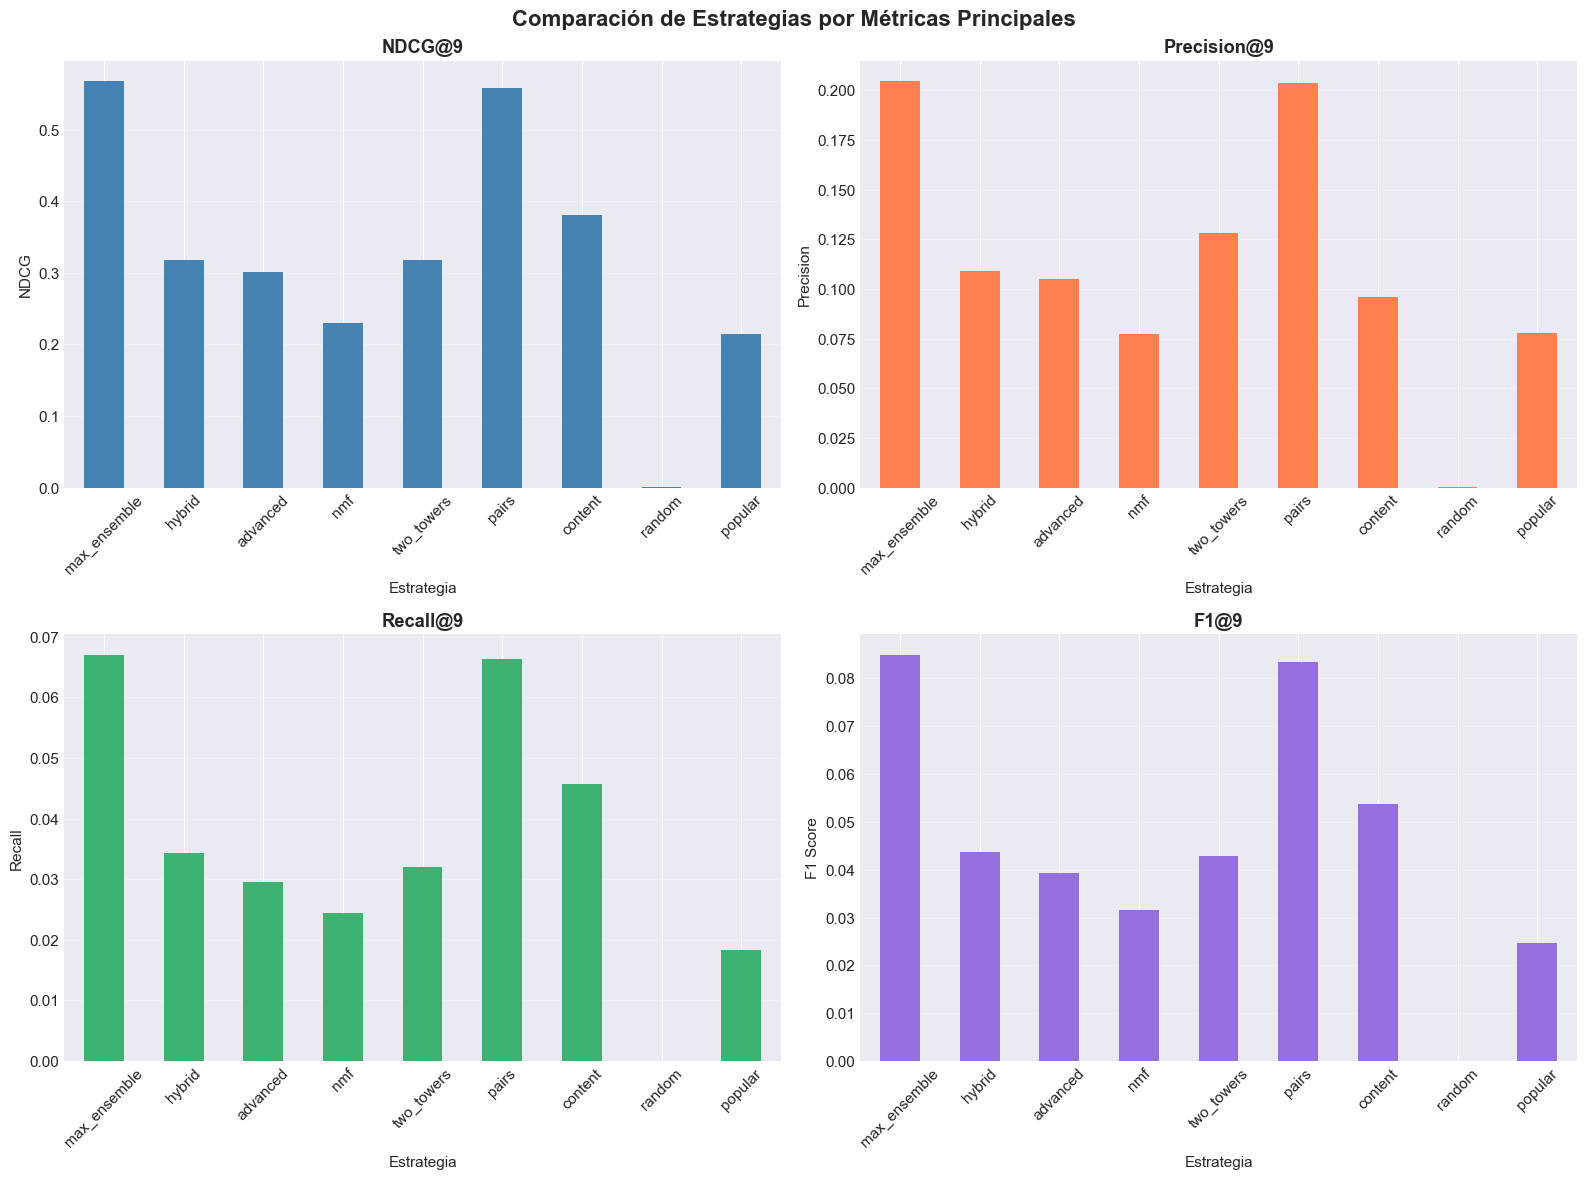

In [61]:
# Visualización 1: Comparación de métricas principales
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Comparación de Estrategias por Métricas Principales", fontsize=16, fontweight="bold")

# NDCG
ax1 = axes[0, 0]
summary_df["ndcg"].plot(kind="bar", ax=ax1, color="steelblue")
ax1.set_title("NDCG@9", fontweight="bold")
ax1.set_ylabel("NDCG")
ax1.set_xlabel("Estrategia")
ax1.tick_params(axis="x", rotation=45)
ax1.grid(axis="y", alpha=0.3)

# Precision
ax2 = axes[0, 1]
summary_df["precision"].plot(kind="bar", ax=ax2, color="coral")
ax2.set_title("Precision@9", fontweight="bold")
ax2.set_ylabel("Precision")
ax2.set_xlabel("Estrategia")
ax2.tick_params(axis="x", rotation=45)
ax2.grid(axis="y", alpha=0.3)

# Recall
ax3 = axes[1, 0]
summary_df["recall"].plot(kind="bar", ax=ax3, color="mediumseagreen")
ax3.set_title("Recall@9", fontweight="bold")
ax3.set_ylabel("Recall")
ax3.set_xlabel("Estrategia")
ax3.tick_params(axis="x", rotation=45)
ax3.grid(axis="y", alpha=0.3)

# F1
ax4 = axes[1, 1]
summary_df["f1"].plot(kind="bar", ax=ax4, color="mediumpurple")
ax4.set_title("F1@9", fontweight="bold")
ax4.set_ylabel("F1 Score")
ax4.set_xlabel("Estrategia")
ax4.tick_params(axis="x", rotation=45)
ax4.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

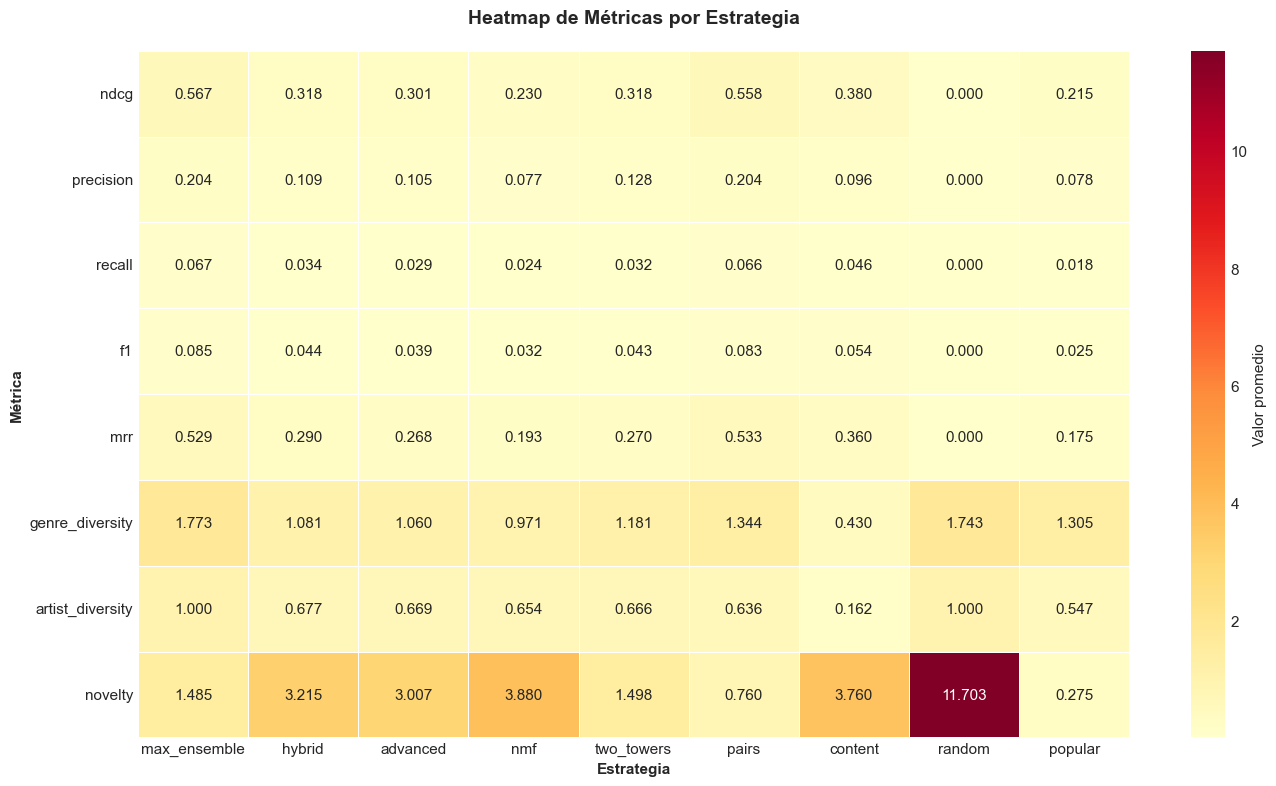

In [62]:
# Visualización 2: Heatmap de todas las métricas
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    summary_df.T,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    cbar_kws={"label": "Valor promedio"},
    ax=ax,
    linewidths=0.5,
)
ax.set_title("Heatmap de Métricas por Estrategia", fontsize=14, fontweight="bold", pad=20)
ax.set_xlabel("Estrategia", fontweight="bold")
ax.set_ylabel("Métrica", fontweight="bold")
plt.tight_layout()
plt.show()

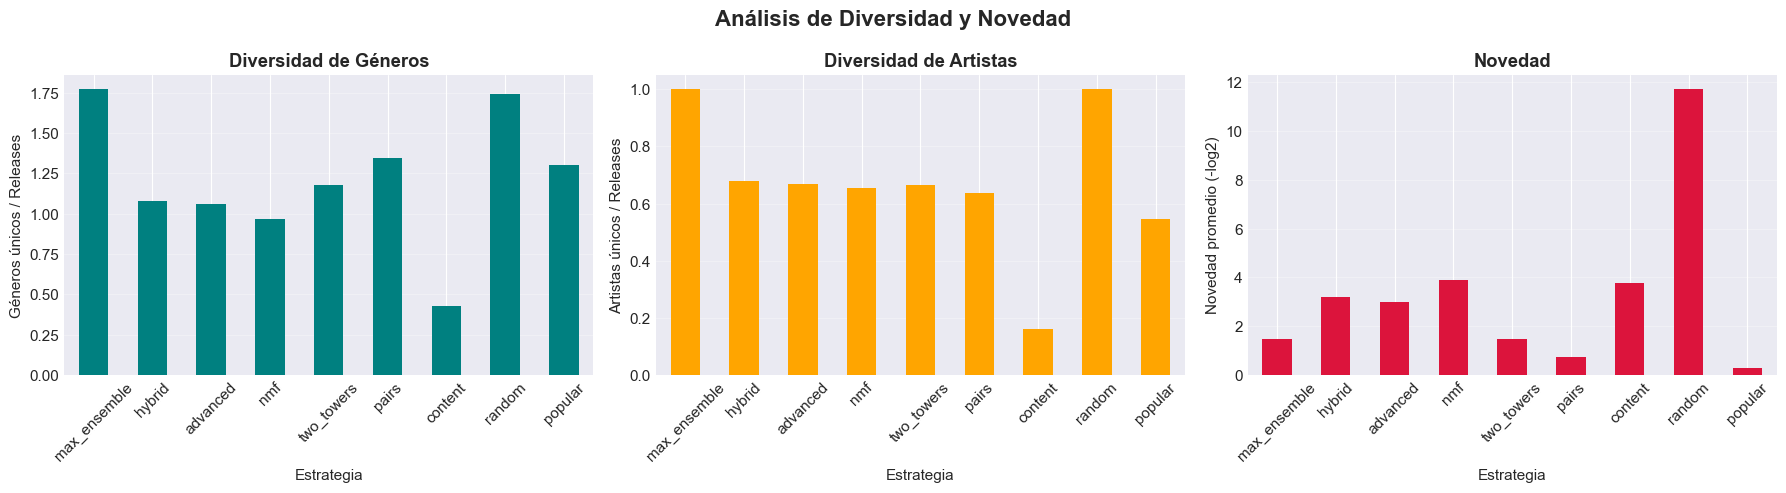

In [63]:
# Visualización 3: Diversidad y Novedad
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Análisis de Diversidad y Novedad", fontsize=16, fontweight="bold")

# Genre Diversity
ax1 = axes[0]
summary_df["genre_diversity"].plot(kind="bar", ax=ax1, color="teal")
ax1.set_title("Diversidad de Géneros", fontweight="bold")
ax1.set_ylabel("Géneros únicos / Releases")
ax1.set_xlabel("Estrategia")
ax1.tick_params(axis="x", rotation=45)
ax1.grid(axis="y", alpha=0.3)

# Artist Diversity
ax2 = axes[1]
summary_df["artist_diversity"].plot(kind="bar", ax=ax2, color="orange")
ax2.set_title("Diversidad de Artistas", fontweight="bold")
ax2.set_ylabel("Artistas únicos / Releases")
ax2.set_xlabel("Estrategia")
ax2.tick_params(axis="x", rotation=45)
ax2.grid(axis="y", alpha=0.3)

# Novelty
ax3 = axes[2]
summary_df["novelty"].plot(kind="bar", ax=ax3, color="crimson")
ax3.set_title("Novedad", fontweight="bold")
ax3.set_ylabel("Novedad promedio (-log2)")
ax3.set_xlabel("Estrategia")
ax3.tick_params(axis="x", rotation=45)
ax3.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

/var/folders/6c/1g3b2t8s1l5ch_c9nch8gppw0000gn/T/ipykernel_27940/1932012056.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 0].boxplot(ndcg_data, labels=strategies)
/var/folders/6c/1g3b2t8s1l5ch_c9nch8gppw0000gn/T/ipykernel_27940/1932012056.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot(precision_data, labels=strategies)
/var/folders/6c/1g3b2t8s1l5ch_c9nch8gppw0000gn/T/ipykernel_27940/1932012056.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot(recall_data, labels=strategies)
/var/folders/6c/1g3b2t8s1l5ch_c9nch8gppw0000gn/T/ipykernel_27940/1932012056.py:33: M

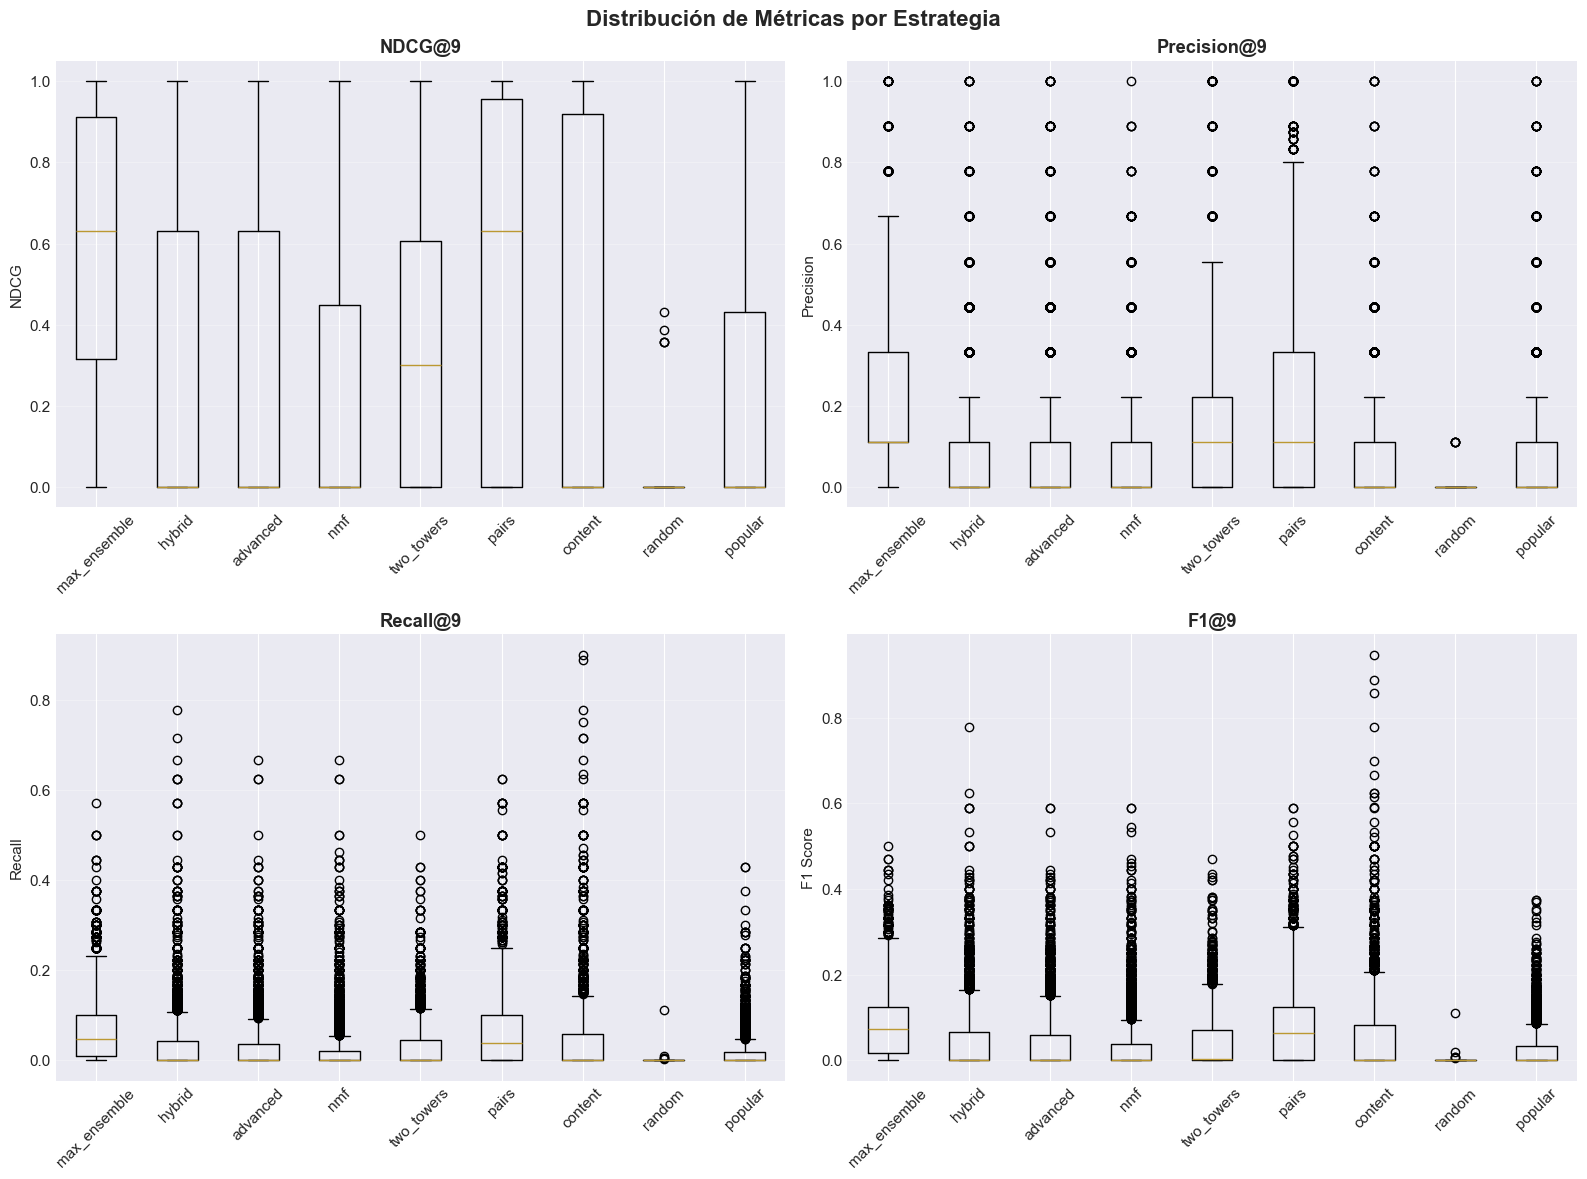

In [64]:
# Visualización 4: Boxplots de distribución de métricas principales
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Distribución de Métricas por Estrategia", fontsize=16, fontweight="bold")

# Preparar datos para boxplots
ndcg_data = [df[f"{s}_ndcg"].dropna() for s in strategies]
precision_data = [df[f"{s}_precision"].dropna() for s in strategies]
recall_data = [df[f"{s}_recall"].dropna() for s in strategies]
f1_data = [df[f"{s}_f1"].dropna() for s in strategies]

# NDCG
axes[0, 0].boxplot(ndcg_data, labels=strategies)
axes[0, 0].set_title("NDCG@9", fontweight="bold")
axes[0, 0].set_ylabel("NDCG")
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].grid(axis="y", alpha=0.3)

# Precision
axes[0, 1].boxplot(precision_data, labels=strategies)
axes[0, 1].set_title("Precision@9", fontweight="bold")
axes[0, 1].set_ylabel("Precision")
axes[0, 1].tick_params(axis="x", rotation=45)
axes[0, 1].grid(axis="y", alpha=0.3)

# Recall
axes[1, 0].boxplot(recall_data, labels=strategies)
axes[1, 0].set_title("Recall@9", fontweight="bold")
axes[1, 0].set_ylabel("Recall")
axes[1, 0].tick_params(axis="x", rotation=45)
axes[1, 0].grid(axis="y", alpha=0.3)

# F1
axes[1, 1].boxplot(f1_data, labels=strategies)
axes[1, 1].set_title("F1@9", fontweight="bold")
axes[1, 1].set_ylabel("F1 Score")
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [65]:
# Ranking de estrategias por métrica
print("=" * 80)
print("RANKING DE ESTRATEGIAS POR MÉTRICA")
print("=" * 80)

for metric in [
    "ndcg",
    "precision",
    "recall",
    "f1",
    "mrr",
    "genre_diversity",
    "artist_diversity",
    "novelty",
]:
    print(f"\n{metric.upper()}:")
    print("-" * 40)
    ranked = summary_df[metric].sort_values(ascending=False)
    for i, (strategy, value) in enumerate(ranked.items(), 1):
        print(f"  {i}. {strategy:15s}: {value:.4f}")

RANKING DE ESTRATEGIAS POR MÉTRICA

NDCG:
----------------------------------------
  1. max_ensemble   : 0.5673
  2. pairs          : 0.5583
  3. content        : 0.3803
  4. hybrid         : 0.3183
  5. two_towers     : 0.3183
  6. advanced       : 0.3011
  7. nmf            : 0.2305
  8. popular        : 0.2146
  9. random         : 0.0004

PRECISION:
----------------------------------------
  1. max_ensemble   : 0.2045
  2. pairs          : 0.2035
  3. two_towers     : 0.1280
  4. hybrid         : 0.1090
  5. advanced       : 0.1049
  6. content        : 0.0960
  7. popular        : 0.0776
  8. nmf            : 0.0771
  9. random         : 0.0001

RECALL:
----------------------------------------
  1. max_ensemble   : 0.0670
  2. pairs          : 0.0663
  3. content        : 0.0457
  4. hybrid         : 0.0343
  5. two_towers     : 0.0320
  6. advanced       : 0.0295
  7. nmf            : 0.0244
  8. popular        : 0.0182
  9. random         : 0.0000

F1:
--------------------------

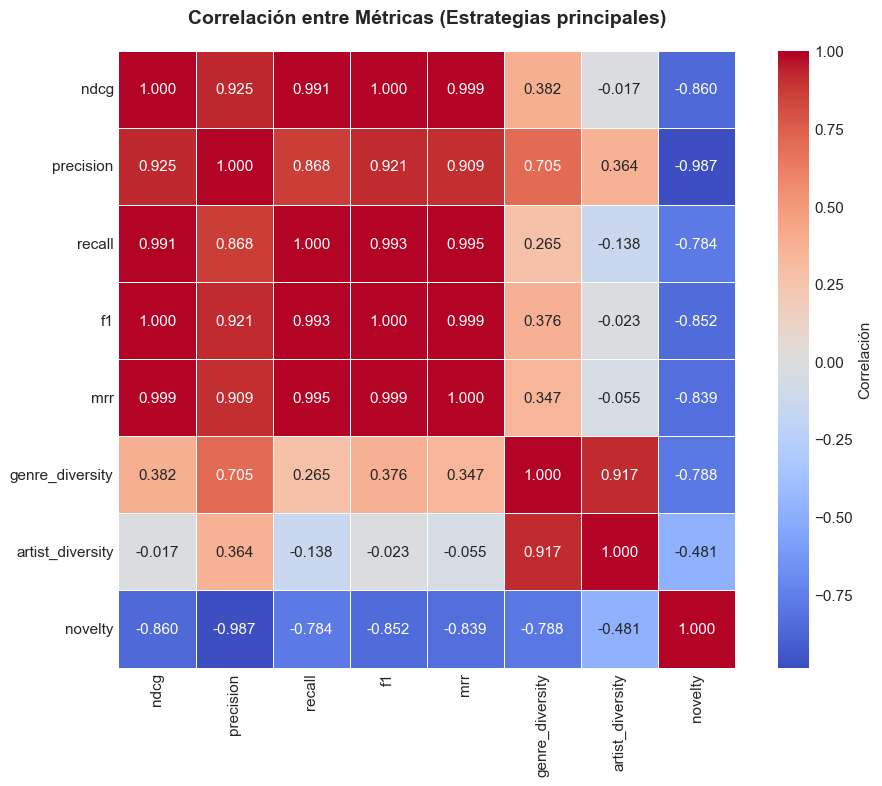

In [66]:
# Análisis de correlación entre métricas (para estrategias principales)
correlation_metrics = [
    "ndcg",
    "precision",
    "recall",
    "f1",
    "mrr",
    "genre_diversity",
    "artist_diversity",
    "novelty",
]
corr_data = []

for strategy in ["hybrid", "advanced", "pairs", "content"]:
    row = {}
    for metric in correlation_metrics:
        col = f"{strategy}_{metric}"
        if col in df.columns:
            row[metric] = df[col].mean()
    corr_data.append(row)

corr_df = pd.DataFrame(corr_data, index=["hybrid", "advanced", "pairs", "content"])

fig, ax = plt.subplots(figsize=(10, 8))
correlation_matrix = corr_df.corr()
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlación"},
    ax=ax,
)
ax.set_title(
    "Correlación entre Métricas (Estrategias principales)", fontsize=14, fontweight="bold", pad=20
)
plt.tight_layout()
plt.show()

In [67]:
# Análisis por tamaño de holdout
df["holdout_category"] = pd.cut(
    df["holdout_size"],
    bins=[0, 20, 50, 100, 200, float("inf")],
    labels=[
        "Muy pequeño (≤20)",
        "Pequeño (21-50)",
        "Mediano (51-100)",
        "Grande (101-200)",
        "Muy grande (>200)",
    ],
)

print("=" * 80)
print("ANÁLISIS POR TAMAÑO DE HOLDOUT")
print("=" * 80)

for category in df["holdout_category"].cat.categories:
    subset = df[df["holdout_category"] == category]
    if len(subset) > 0:
        print(f"\n{category} ({len(subset)} usuarios):")
        print("-" * 40)
        for strategy in ["hybrid", "advanced", "pairs", "content"]:
            ndcg_col = f"{strategy}_ndcg"
            if ndcg_col in subset.columns:
                mean_ndcg = subset[ndcg_col].mean()
                print(f"  {strategy:15s}: NDCG promedio = {mean_ndcg:.4f}")

ANÁLISIS POR TAMAÑO DE HOLDOUT

Muy pequeño (≤20) (2162 usuarios):
----------------------------------------
  hybrid         : NDCG promedio = 0.2035
  advanced       : NDCG promedio = 0.1702
  pairs          : NDCG promedio = 0.4394
  content        : NDCG promedio = 0.3638

Pequeño (21-50) (1241 usuarios):
----------------------------------------
  hybrid         : NDCG promedio = 0.3423
  advanced       : NDCG promedio = 0.3404
  pairs          : NDCG promedio = 0.5891
  content        : NDCG promedio = 0.3787

Mediano (51-100) (596 usuarios):
----------------------------------------
  hybrid         : NDCG promedio = 0.4442
  advanced       : NDCG promedio = 0.4439
  pairs          : NDCG promedio = 0.6874
  content        : NDCG promedio = 0.4076

Grande (101-200) (345 usuarios):
----------------------------------------
  hybrid         : NDCG promedio = 0.5288
  advanced       : NDCG promedio = 0.5206
  pairs          : NDCG promedio = 0.7666
  content        : NDCG promedio = 0.

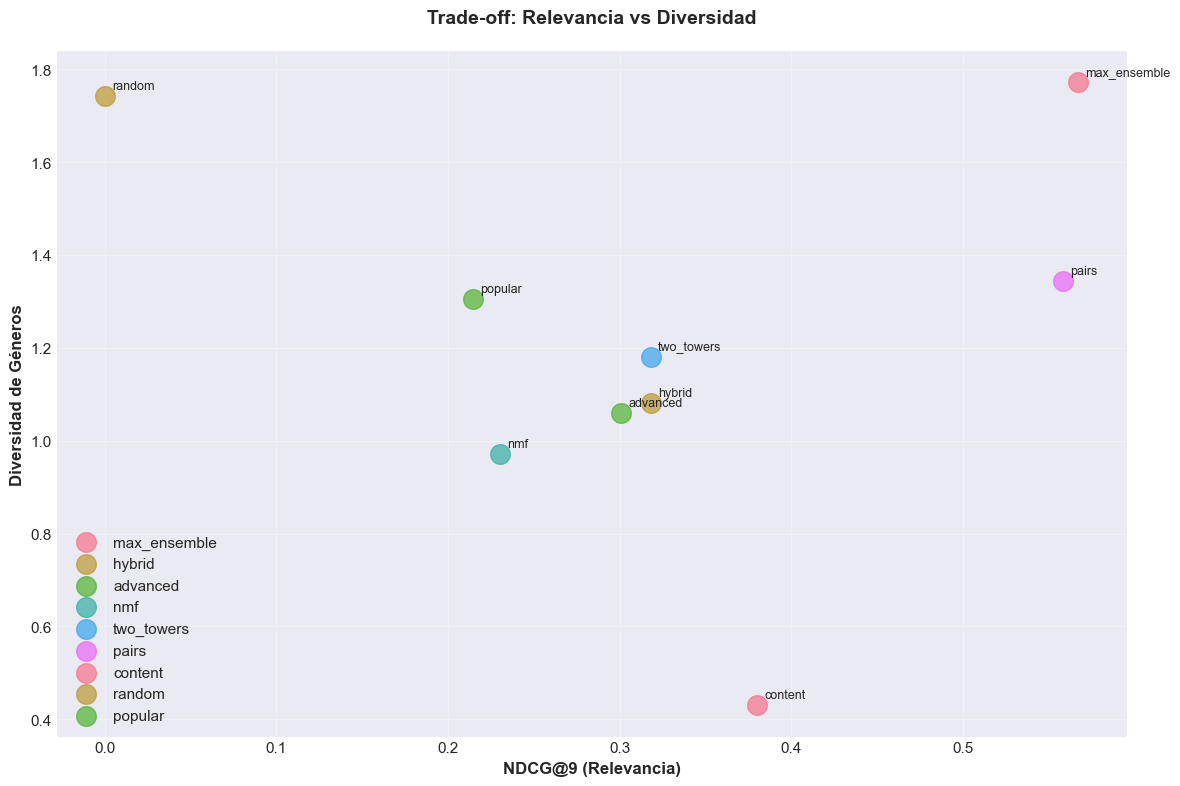

In [68]:
# Visualización 5: Trade-off entre relevancia y diversidad
fig, ax = plt.subplots(figsize=(12, 8))

for strategy in strategies:
    ndcg_col = f"{strategy}_ndcg"
    div_col = f"{strategy}_genre_diversity"

    if ndcg_col in df.columns and div_col in df.columns:
        mean_ndcg = df[ndcg_col].mean()
        mean_div = df[div_col].mean()
        ax.scatter(mean_ndcg, mean_div, s=200, alpha=0.7, label=strategy)
        ax.annotate(
            strategy, (mean_ndcg, mean_div), xytext=(5, 5), textcoords="offset points", fontsize=9
        )

ax.set_xlabel("NDCG@9 (Relevancia)", fontweight="bold", fontsize=12)
ax.set_ylabel("Diversidad de Géneros", fontweight="bold", fontsize=12)
ax.set_title("Trade-off: Relevancia vs Diversidad", fontsize=14, fontweight="bold", pad=20)
ax.legend(loc="best", framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

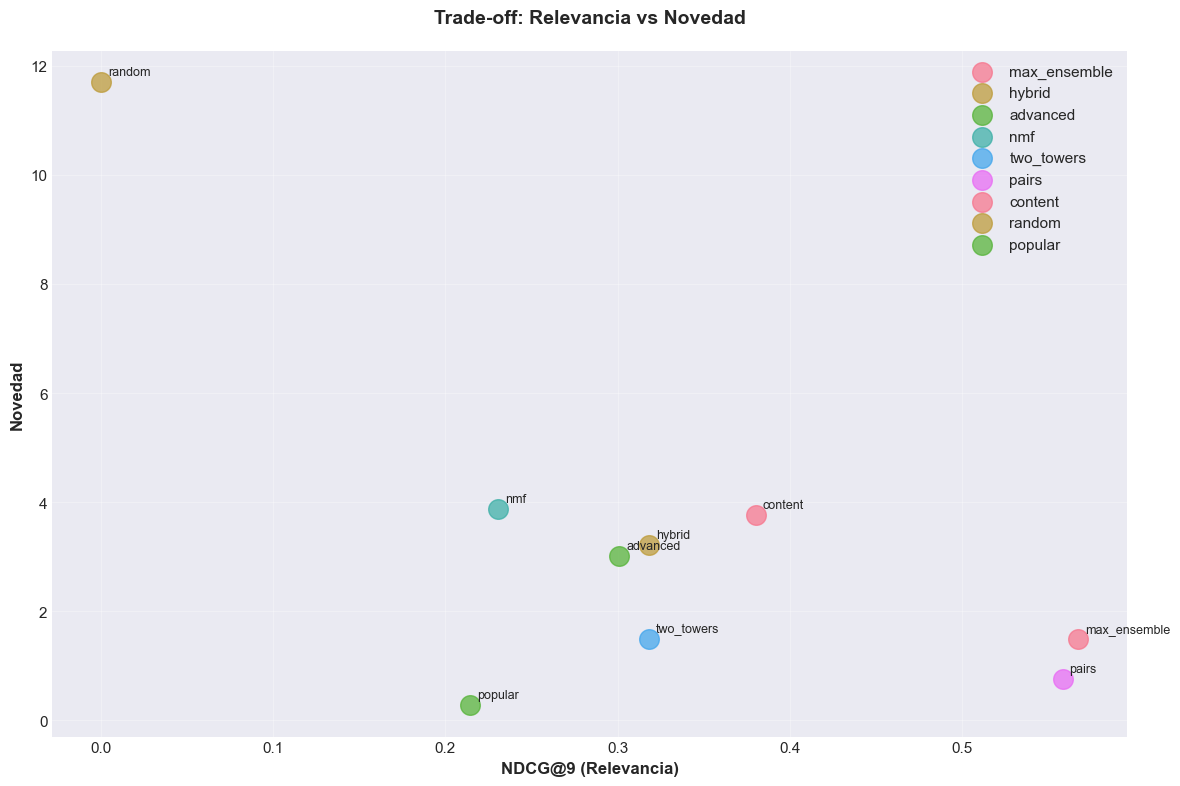

In [69]:
# Visualización 6: Trade-off entre relevancia y novedad
fig, ax = plt.subplots(figsize=(12, 8))

for strategy in strategies:
    ndcg_col = f"{strategy}_ndcg"
    nov_col = f"{strategy}_novelty"

    if ndcg_col in df.columns and nov_col in df.columns:
        mean_ndcg = df[ndcg_col].mean()
        mean_nov = df[nov_col].mean()
        ax.scatter(mean_ndcg, mean_nov, s=200, alpha=0.7, label=strategy)
        ax.annotate(
            strategy, (mean_ndcg, mean_nov), xytext=(5, 5), textcoords="offset points", fontsize=9
        )

ax.set_xlabel("NDCG@9 (Relevancia)", fontweight="bold", fontsize=12)
ax.set_ylabel("Novedad", fontweight="bold", fontsize=12)
ax.set_title("Trade-off: Relevancia vs Novedad", fontsize=14, fontweight="bold", pad=20)
ax.legend(loc="best", framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusiones

### Resumen de Hallazgos:

1. **Mejor relevancia (NDCG)**: 
   - **max_ensemble** lidera con NDCG de 0.5673, superando significativamente a todas las demás estrategias
   - **pairs** es el segundo mejor con 0.5583 (diferencia mínima de 0.009), demostrando que la co-ocurrencia es muy efectiva
   - **content** ocupa el tercer lugar con 0.3803, siendo la mejor opción basada en contenido
   - Las estrategias basadas en deep learning (**two_towers**: 0.3183, **advanced**: 0.3011) tienen rendimiento moderado
   - **max_ensemble** supera al baseline **hybrid** en un 78% (0.5673 vs 0.3183)

2. **Mejor precisión**: 
   - **max_ensemble** (0.2045) y **pairs** (0.2035) están prácticamente empatados en el primer lugar
   - **two_towers** muestra buena precisión (0.1280) a pesar de su NDCG moderado
   - Las estrategias híbridas (**hybrid**: 0.1090, **advanced**: 0.1049) tienen precisión moderada
   - **content** tiene menor precisión (0.0960) pero compensa con mejor recall

3. **Mejor diversidad**: 
   - **max_ensemble** logra la mejor diversidad de géneros (1.7726) y casi perfecta diversidad de artistas (0.9998)
   - **pairs** ofrece buena diversidad de géneros (1.3442) pero menor diversidad de artistas (0.6361)
   - **content** tiene muy baja diversidad de géneros (0.4300) y artistas (0.1624), siendo la más homogénea
   - **random** tiene alta diversidad pero sin relevancia (NDCG: 0.0004)

4. **Mejor novedad**: 
   - **random** tiene la mayor novedad (11.7031) pero sin relevancia práctica
   - **nmf** (3.8799) y **content** (3.7605) ofrecen alta novedad con relevancia moderada
   - **max_ensemble** tiene novedad moderada (1.4854), balanceando descubrimiento con relevancia
   - **pairs** tiene baja novedad (0.7603), tendiendo a recomendar items más populares

5. **Trade-offs identificados**:
   - **Relevancia vs Diversidad**: max_ensemble logra el mejor balance, siendo líder en ambas métricas simultáneamente
   - **Relevancia vs Novedad**: Existe un trade-off claro - max_ensemble y pairs priorizan relevancia sobre novedad, mientras que nmf y content ofrecen más novedad pero menos relevancia
   - **Precisión vs Recall**: content tiene mejor recall (0.0457) que precision (0.0960), mientras que max_ensemble mantiene mejor balance

### Análisis por Tamaño de Holdout:

- **Usuarios con historial muy pequeño (≤20)**: **pairs** (0.4394) y **content** (0.3638) funcionan mejor que hybrid/advanced
- **Usuarios con historial grande (>200)**: **pairs** alcanza NDCG de 0.8317, seguido de hybrid (0.5954)
- El rendimiento mejora consistentemente con el tamaño del historial para todas las estrategias

### Posibles mejoras:

- **Para usuarios con historial corto (≤20 items)**: 
  - Usar **pairs** o **content** como estrategias principales, ya que funcionan mejor con datos limitados
  - **max_ensemble** puede ser efectivo pero requiere validación con este segmento específico

- **Para usuarios con historial largo (>200 items)**: 
  - **pairs** muestra el mejor rendimiento (NDCG: 0.8317), ideal para usuarios con mucho historial
  - **max_ensemble** es la mejor opción general considerando todas las métricas simultáneamente
  - Las estrategias híbridas (**hybrid**, **advanced**) mejoran significativamente con más datos

- **Para maximizar descubrimiento**: 
  - Usar **nmf** o **content** si se prioriza la novedad sobre la relevancia
  - Considerar un enfoque híbrido que combine max_ensemble con un componente de exploración para balancear relevancia y novedad

- **Para maximizar relevancia**:
  - **max_ensemble** es la estrategia recomendada como sistema principal, siendo líder en NDCG, Precision, Recall y F1
  - **pairs** es una excelente alternativa, especialmente para usuarios con historial extenso
  - El sistema max_ensemble demuestra una mejora del 78% sobre el baseline hybrid, validando su efectividad


In [70]:
# Guardar resumen en CSV
summary_df.to_csv("../resultados_evaluacion_resumen.csv")
print("Resumen guardado en: resultados_evaluacion_resumen.csv")

# Estadísticas adicionales
print("\n" + "=" * 80)
print("ESTADÍSTICAS ADICIONALES")
print("=" * 80)
print(f"\nTotal de usuarios evaluados: {len(df)}")
print(f"Tamaño promedio de holdout: {df['holdout_size'].mean():.1f}")
print(f"Tamaño mínimo de holdout: {df['holdout_size'].min()}")
print(f"Tamaño máximo de holdout: {df['holdout_size'].max()}")

# Usuarios con mejor rendimiento por estrategia
print("\n" + "=" * 80)
print("TOP 5 USUARIOS POR ESTRATEGIA (NDCG)")
print("=" * 80)
for strategy in ["hybrid", "advanced", "pairs", "content"]:
    ndcg_col = f"{strategy}_ndcg"
    if ndcg_col in df.columns:
        top_users = df.nlargest(5, ndcg_col)[["user_id", "holdout_size", ndcg_col]]
        print(f"\n{strategy.upper()}:")
        print(top_users.to_string(index=False))

Resumen guardado en: resultados_evaluacion_resumen.csv

ESTADÍSTICAS ADICIONALES

Total de usuarios evaluados: 4600
Tamaño promedio de holdout: 58.4
Tamaño mínimo de holdout: 6
Tamaño máximo de holdout: 3032

TOP 5 USUARIOS POR ESTRATEGIA (NDCG)

HYBRID:
             user_id  holdout_size  hybrid_ndcg
            SummaRed            11          1.0
NecroticWurmKvltLord            98          1.0
          Sunsneezia           194          1.0
       TheWatchman71           332          1.0
          Train12345            20          1.0

ADVANCED:
             user_id  holdout_size  advanced_ndcg
            SummaRed            11            1.0
NecroticWurmKvltLord            98            1.0
          Sunsneezia           194            1.0
               Geomi            65            1.0
       TheWatchman71           332            1.0

PAIRS:
       user_id  holdout_size  pairs_ndcg
cloakanddagger           635         1.0
   CamJCollins             7         1.0
    carinelfic 